In [ ]:
import pandas as pd
import joblib

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# Análisis exploratorio y entrenamiento del modelo de predicción de precios de casas

# Esto es para cargar los datos
df = pd.read_csv("train.csv")

# 1. Elimino columnas con muchos valores faltantes o poco relevantes
df = df.drop(columns=["PoolQC", "MiscFeature", "Alley", "Fence"])

# 2. separar X y y
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

# 3. Identifico columnas
cat_cols = X.select_dtypes(include=["object"]).columns
num_cols = X.select_dtypes(exclude=["object"]).columns

# 4. Transformaciones - encoder

# numéricas → rellenar con mediana
num_transformer = SimpleImputer(strategy="median")

# categóricas → OneHotEncoder
cat_transformer = OneHotEncoder(handle_unknown="ignore")

# combinar
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_cols),
        ("cat", cat_transformer, cat_cols)
    ]
)

# 5. pipeline completo
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

# 6. hiperparámetros (IMPORTANTE: prefijo "model__")
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [8, 10, 12],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

# 7. grid search
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid_search.fit(X, y)

best_model = grid_search.best_estimator_

# 8. guardar TODO el pipeline
joblib.dump(best_model, "modelo_pipeline.pkl")

print("Mejores parámetros:", grid_search.best_params_)
print("Mejor MAE:", -grid_search.best_score_)

C:\Users\japi_.JAVIER\AppData\Local\Temp\ipykernel_6804\581296935.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object"]).columns


Mejores parámetros: {'model__max_depth': 12, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Mejor MAE: 17735.561348579675


             feature  importance
4   num__OverallQual    0.580538
16    num__GrLivArea    0.108575
12  num__TotalBsmtSF    0.037656
14     num__2ndFlrSF    0.033082
9    num__BsmtFinSF1    0.029723
13     num__1stFlrSF    0.022722
26   num__GarageCars    0.022013
27   num__GarageArea    0.013997
3       num__LotArea    0.012149
6     num__YearBuilt    0.008833


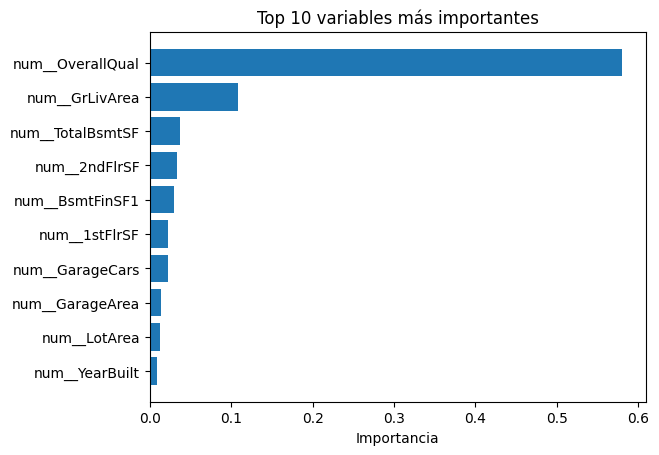

In [79]:
import pandas as pd
import matplotlib.pyplot as plt

# obtener modelo dentro del pipeline
rf_model = best_model.named_steps["model"]

# nombres de features transformadas
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

# importancias
importances = rf_model.feature_importances_

# dataframe ordenado
feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(feat_imp.head(10))

plt.figure()
plt.barh(feat_imp["feature"][:10], feat_imp["importance"][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 variables más importantes")
plt.xlabel("Importancia")
plt.show()